# 04 - Qdrant Indexing Pipeline

Notebook operativo per costruire (e verificare) l'indice vettoriale Qdrant a partire da `data/laws_dataset_clean`.

## Obiettivo
- rendere esplicito il passaggio dal preprocessing dati (notebook 03) all'indicizzazione
- controllare la qualita del chunk refinement
- verificare embedding, payload metadata e stato reale della collection
- produrre artifact di run usabili nel notebook RAG successivo

## Sezione A - Setup ambiente e import

### Cosa fa la cella seguente
- risolve la root del repository in modo robusto
- prepara `sys.path` per importare `src/legal_indexing`
- carica variabili da `.env`
- importa i moduli della pipeline di indexing


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Evita warning matplotlib su directory non scrivibile in alcuni ambienti.
os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.mplconfig').resolve()))


def _find_repo_root_for_bootstrap(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'notebooks' / 'pipelines' / 'common' / 'bootstrap.py').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Project root non trovato. Avvia il notebook dentro il repository.')


_BOOTSTRAP_ROOT = _find_repo_root_for_bootstrap(Path.cwd().resolve())
if str(_BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP_ROOT))

from notebooks.pipelines.common.bootstrap import bootstrap_notebook

ROOT, SRC = bootstrap_notebook(start=Path.cwd().resolve())

from legal_indexing.io import load_dataset_bundle, validate_dataset
from legal_indexing.chunk_refinement import refine_chunks_with_diagnostics
from legal_indexing.embeddings import discover_utopia_models, debug_utopia_embedding_connection
from legal_indexing.pipeline import run_indexing_pipeline
from legal_indexing.settings import IndexingConfig, make_chunking_profile

print('ROOT:', ROOT)
print('Python:', sys.executable)


ROOT: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite
Python: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/.venv/bin/python3.13


## Sezione B - Configurazione run

### Cosa fa la cella seguente
- imposta i path principali (`dataset`, `qdrant`, `artifacts`)
- definisce parametri di esecuzione (`subset`, `force_reembed`, `strict_validation`)
- configura il provider embedding Utopia
- abilita il contract gate di coverage evaluation->indice
- crea `ChunkingProfile` e `IndexingConfig`

### Output atteso
Uno snapshot chiaro della configurazione effettiva della run.


In [2]:
# Path principali: input dataset, storage Qdrant locale, artifact run.
DATASET_DIR = ROOT / 'data/laws_dataset_clean'
QDRANT_PATH = ROOT / 'data/indexes/qdrant'
ARTIFACTS_ROOT = ROOT / 'data/qdrant_indexing'

# Contract gate: blocca indexing se coverage evaluation->indice < soglia.
INDEX_CONTRACT_ENFORCE_EVAL_COVERAGE = True
INDEX_CONTRACT_MIN_EVAL_COVERAGE = 0.95
EVAL_QUESTIONS_CSV = ROOT / 'data/evaluation/questions.csv'
EVAL_QUESTIONS_NO_HINT_CSV = ROOT / 'data/evaluation/questions_no_hint.csv'

# Controlli run: subset per smoke, re-embed completo, strict mode.
SUBSET_LIMIT = None  # es. 500 per run veloci
FORCE_REEMBED = False
STRICT_VALIDATION = True

# Config embedding Utopia.
EMBEDDING_PROVIDER = 'utopia'
UTOPIA_BASE_URL = os.getenv('UTOPIA_BASE_URL', 'https://utopia.hpc4ai.unito.it/api')
UTOPIA_EMBED_API_MODE = os.getenv('UTOPIA_EMBED_API_MODE', 'auto')  # auto | openai | ollama
UTOPIA_EMBED_URL = os.getenv('UTOPIA_EMBED_URL', 'https://utopia.hpc4ai.unito.it/ollama/api/embed')
EMBEDDING_MODEL = os.getenv('UTOPIA_EMBED_MODEL', 'SLURM.nomic-embed-text:latest')
EMBEDDING_API_KEY = os.getenv('UTOPIA_API_KEY', '')

# Config sparse/hybrid index (dense + BM25-like).
SPARSE_ENABLED = True
SPARSE_VECTOR_NAME = 'bm25'
SPARSE_MIN_TOKEN_LEN = 2
SPARSE_STOPWORDS_LANG = 'it'
SPARSE_STORE_ARTIFACTS = True
SPARSE_ANALYZER = 'it_legal'

# Profilo di chunk refinement: default bilanciato per retrieval/espansione successiva.
chunk_profile = make_chunking_profile(
    'balanced',
    min_words_merge=20,
    max_words_split=220,
    overlap_words_split=40,
)

# Config globale della pipeline di indexing.
config = IndexingConfig(
    dataset_dir=DATASET_DIR,
    qdrant_path=QDRANT_PATH,
    artifacts_root=ARTIFACTS_ROOT,
    embedding_provider=EMBEDDING_PROVIDER,
    utopia_base_url=UTOPIA_BASE_URL,
    utopia_embed_api_mode=UTOPIA_EMBED_API_MODE,
    utopia_embed_url=UTOPIA_EMBED_URL,
    embedding_model=EMBEDDING_MODEL,
    embedding_api_key=EMBEDDING_API_KEY,
    chunking_profile=chunk_profile,
    subset_limit=SUBSET_LIMIT,
    force_reembed=FORCE_REEMBED,
    strict_validation=STRICT_VALIDATION,
    sparse_enabled=SPARSE_ENABLED,
    sparse_vector_name=SPARSE_VECTOR_NAME,
    sparse_min_token_len=SPARSE_MIN_TOKEN_LEN,
    sparse_stopwords_lang=SPARSE_STOPWORDS_LANG,
    sparse_store_artifacts=SPARSE_STORE_ARTIFACTS,
    sparse_analyzer=SPARSE_ANALYZER,
    index_contract_enforce_eval_coverage=INDEX_CONTRACT_ENFORCE_EVAL_COVERAGE,
    index_contract_min_eval_coverage=INDEX_CONTRACT_MIN_EVAL_COVERAGE,
    eval_questions_csv=EVAL_QUESTIONS_CSV,
    eval_questions_no_hint_csv=EVAL_QUESTIONS_NO_HINT_CSV,
)

# Snapshot leggibile della configurazione effettiva.
config.to_dict()



{'dataset_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean',
 'qdrant_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexes/qdrant',
 'artifacts_root': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing',
 'collection_name': None,
 'collection_prefix': 'laws_clean',
 'embedding_provider': 'utopia',
 'utopia_base_url': 'https://utopia.hpc4ai.unito.it/api',
 'utopia_embed_api_mode': 'auto',
 'utopia_embed_url': 'https://utopia.hpc4ai.unito.it/ollama/api/embed',
 'embedding_model': 'SLURM.nomic-embed-text:latest',
 'embedding_api_key_set': True,
 'embedding_batch_size': 32,
 'embedding_timeout_seconds': 60.0,
 'chunking_profile': {'profile_id': 'balanced',
  'min_words_merge': 20,
  'max_words_split': 220,
  'overlap_words_split': 40},
 'force_reembed'

## Sezione C - Debug embeddings (fail-fast)

### Cosa fa la cella seguente
- interroga il catalogo modelli Utopia
- esegue una probe di embedding
- applica fallback model/transport se disponibile
- blocca il flusso se la connettivita embedding non e valida

In [3]:
# 1) Catalogo modelli disponibile lato Utopia (diagnostica rapida).
catalog = discover_utopia_models(config)
print('Catalog discovery:', json.dumps({
    'ok': catalog.get('ok'),
    'count': catalog.get('count'),
    'status_code': catalog.get('status_code'),
    'embedding_like_models': catalog.get('embedding_like_models', [])[:20],
    'error': catalog.get('error'),
}, ensure_ascii=False, indent=2))

# 2) Probe embedding fail-fast: se fallisce, blocca subito il notebook.
try:
    debug_info = debug_utopia_embedding_connection(
        config,
        probe_text='Verifica connessione embedding Utopia per notebook 04',
    )

    # Se la diagnostica trova un modello alternativo funzionante, aggiornalo per il run.
    resolved_model = debug_info.get('resolved_model')
    if resolved_model and resolved_model != config.embedding_model:
        print(f"Embedding model fallback selected: {resolved_model}")
        config = config.with_overrides(embedding_model=resolved_model)

    UTOPIA_DEBUG_OK = True
    print('Utopia embedding connection: OK')
    print(json.dumps(debug_info, ensure_ascii=False, indent=2))
except Exception as exc:
    UTOPIA_DEBUG_OK = False
    print('Utopia embedding connection: FAIL')
    print(str(exc))
    raise


Catalog discovery: {
  "ok": true,
  "count": 9,
  "status_code": 200,
  "embedding_like_models": [
    "mxbai-embed-large:latest",
    "nomic-embed-text:latest",
    "qwen3-embedding:latest"
  ],
  "error": null
}
Utopia embedding connection: OK
{
  "provider": "utopia",
  "model": "SLURM.nomic-embed-text:latest",
  "configured_mode": "auto",
  "base_url": "https://utopia.hpc4ai.unito.it/api",
  "embed_url": "https://utopia.hpc4ai.unito.it/ollama/api/embed",
  "batch_size": 32,
  "timeout_seconds": 60.0,
  "success": true,
  "model_catalog": {
    "ok": true,
    "count": 9,
    "status_code": 200,
    "embedding_like_models": [
      "mxbai-embed-large:latest",
      "nomic-embed-text:latest",
      "qwen3-embedding:latest"
    ],
    "error": null
  },
  "model_candidates": [
    "SLURM.nomic-embed-text:latest",
    "nomic-embed-text:latest",
    "SLURM.nomic-embed-text",
    "mxbai-embed-large:latest",
    "qwen3-embedding:latest",
    "SLURM.mxbai-embed-large:latest",
    "SLURM.q

## Sezione D - Validazione dataset in input

### Cosa fa la cella seguente
- verifica presenza file richiesti
- verifica campi minimi necessari nei chunk
- controlla i prerequisiti del manifest (`ready_to_embedding`)

### Come leggere il risultato
L'output deve essere privo di errori bloccanti prima di procedere alle trasformazioni.


In [4]:
# Validazione formale dataset: schema, presenza file, campi minimi.
validation = validate_dataset(config.resolved_dataset_dir, strict=config.strict_validation)
validation


DatasetValidationResult(dataset_dir=PosixPath('/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean'), manifest_path=PosixPath('/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/manifest.json'), required_files={'manifest': True, 'laws': True, 'articles': True, 'notes': True, 'edges': True, 'events': True, 'chunks': True}, counts={'laws': 3145, 'articles': 17774, 'notes': 8345, 'edges': 41400, 'events': 26692, 'chunks': 74517}, missing_chunk_fields={'chunk_id': 0, 'passage_id': 0, 'article_id': 0, 'law_id': 0, 'chunk_seq': 0, 'text': 0, 'text_for_embedding': 0, 'law_status': 0, 'article_is_abrogated': 0, 'passage_label': 0, 'related_law_ids': 0, 'relation_types': 0, 'inbound_law_ids': 0, 'outbound_law_ids': 0, 'index_views': 0}, errors=(), warnings=())

## Sezione E - Chunk refinement e KPI di trasformazione

### Cosa fa la cella seguente
- carica bundle e passages dal dataset
- applica il refinement deterministico
- mostra KPI di alto livello (input/output, merge, split)
- stampa un esempio concreto di chunk refined con tracciabilita alla sorgente

### Collegamento con notebook 03 e notebook RAG
Qui avviene la transizione operativa dai chunk article-centric a chunk ottimizzati per retrieval vettoriale.


In [5]:
# Caricamento bundle dataset (passages + metadati articolo + manifest).
bundle = load_dataset_bundle(config.resolved_dataset_dir)

# Applicazione subset opzionale per smoke test veloci.
passages = bundle.passages[: config.subset_limit] if config.subset_limit else bundle.passages

# Chunk refinement deterministico secondo il profilo configurato.
refined_chunks, diag = refine_chunks_with_diagnostics(
    passages,
    bundle.article_order_by_id,
    config.chunking_profile,
)

# KPI sintetici per capire l'effetto della trasformazione notebook03 -> indexing.
kpi_rows = [
    ("Input passages", len(passages)),
    ("Output refined chunks", len(refined_chunks)),
    ("Merged units", diag.merged_units),
    ("Split units", diag.split_units),
    ("Chunking profile", diag.profile_id),
]
kpi_df = pd.DataFrame(kpi_rows, columns=["Metrica", "Valore"])
display(kpi_df)

print('Input word stats:', diag.input_word_stats)
print('Output word stats:', diag.output_word_stats)

# Esempio concreto di chunk risultato, con collegamento alle sorgenti.
if refined_chunks:
    sample = refined_chunks[0]
    print('Sample refined chunk_id:', sample.chunk_id)
    print('Source passages:', sample.source_passage_ids)
    print('Article order / chunk order:', sample.article_order_in_law, '/', sample.article_chunk_order)
    print('Embedding text preview:')
    print(sample.text_for_embedding[:500])


,Metrica,Valore
0,Input passages,74436
1,Output refined chunks,50978
2,Merged units,20050
3,Split units,223
4,Chunking profile,balanced


Input word stats: {'count': 74436.0, 'min': 1.0, 'p50': 24.0, 'p90': 71.0, 'p99': 151.0, 'max': 4200.0}
Output word stats: {'count': 50978.0, 'min': 1.0, 'p50': 40.0, 'p90': 87.0, 'p99': 212.0, 'max': 220.0}
Sample refined chunk_id: vda:lr:1950-10-10:1#art:unico#rc:0-0#u:0#s:0
Source passages: ('vda:lr:1950-10-10:1#art:unico#p:intro',)
Article order / chunk order: 0 / 0
Embedding text preview:
[LR 1950-10-10 n.1] Legge regionale 10 ottobre 1950, n. 1 - Testo vigente | Art. unico | passages: intro

Legge regionale 10 ottobre 1950, n. 1 - Testo vigente Legge regionale 10 ottobre 1950, n. 1 Classificazione delle strade di interesse regionale. (B.U. 15 novembre 1950). (Abrogata dall'art. 20, comma 1, della L.R. 20 novembre 2006, n. 26 )


### Analisi distribuzioni chunk (grafici)

### Cosa fa la cella seguente
- confronta lunghezze testo prima/dopo refinement
- misura quanti passages sorgente confluiscono in ogni refined chunk
- evidenzia gli articoli che generano piu chunk

### Perche é utile
Aiuta a verificare se la granularita ottenuta e coerente con l'obiettivo di retrieval.


,before_passages_words,after_refined_words,source_passages_per_chunk
count,74436.000000,50978.000000,50978.000000
mean,33.412193,49.151202,1.469261
std,49.854829,33.699146,0.678651
min,1.000000,1.000000,1.000000
50%,24.000000,40.000000,1.000000
90%,71.000000,87.000000,2.000000
95%,90.250000,111.000000,3.000000
99%,151.000000,212.000000,4.000000
max,4200.000000,220.000000,10.000000


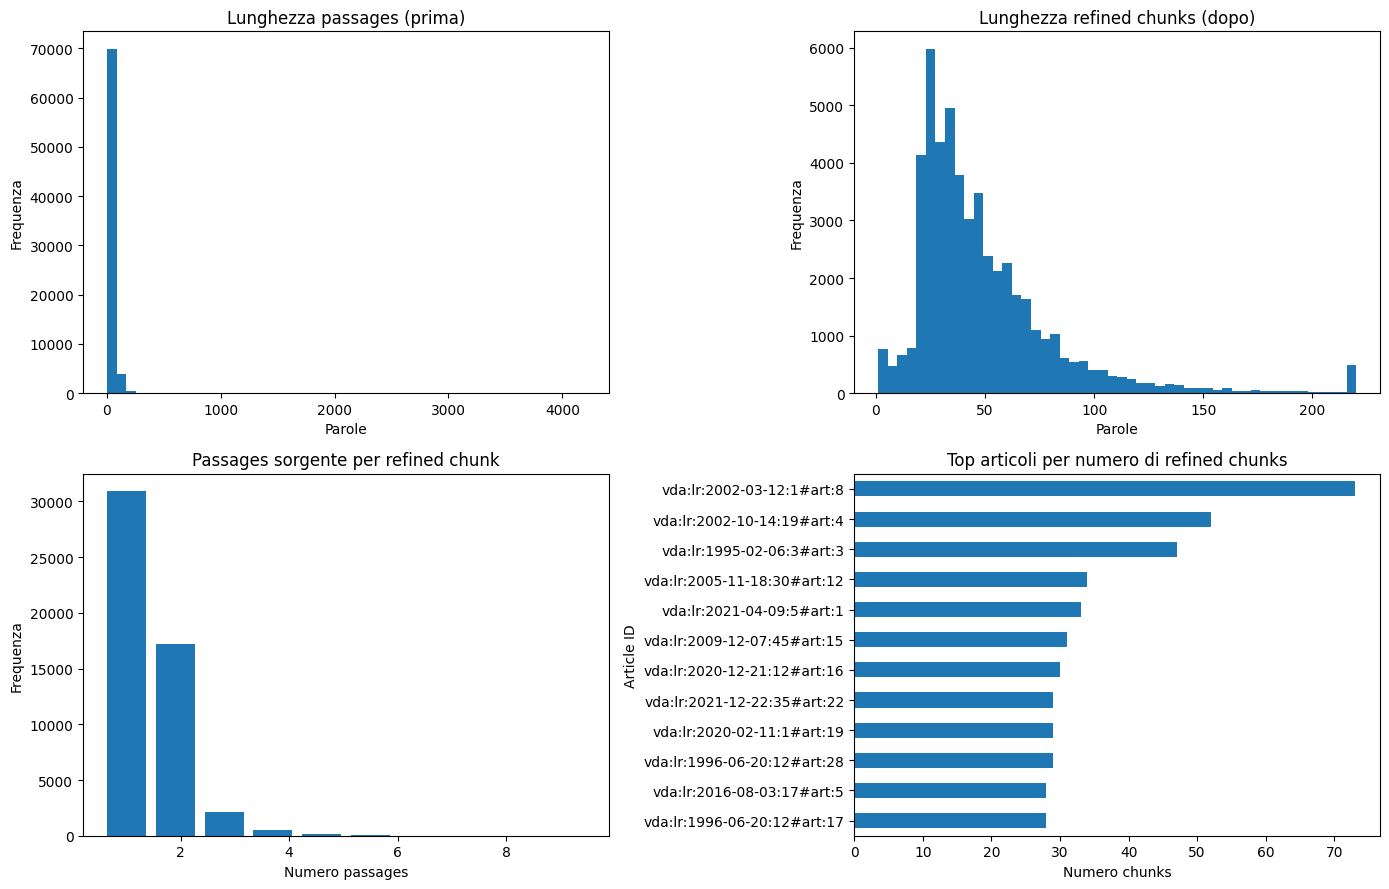

In [6]:
# Distribuzioni principali per spiegare come sono stati costruiti i chunk.
before_sizes = [len((p.text or '').split()) for p in passages]
after_sizes = [len((c.text or '').split()) for c in refined_chunks]
source_passages_per_chunk = [len(c.source_passage_ids) for c in refined_chunks]

article_chunk_counts = pd.Series([c.article_id for c in refined_chunks], dtype='string').value_counts()

stats_df = pd.DataFrame({
    'before_passages_words': pd.Series(before_sizes),
    'after_refined_words': pd.Series(after_sizes),
    'source_passages_per_chunk': pd.Series(source_passages_per_chunk),
})
display(stats_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(before_sizes, bins=50)
axes[0, 0].set_title('Lunghezza passages (prima)')
axes[0, 0].set_xlabel('Parole')
axes[0, 0].set_ylabel('Frequenza')

axes[0, 1].hist(after_sizes, bins=50)
axes[0, 1].set_title('Lunghezza refined chunks (dopo)')
axes[0, 1].set_xlabel('Parole')
axes[0, 1].set_ylabel('Frequenza')

bins = sorted(set(source_passages_per_chunk)) if source_passages_per_chunk else [1]
axes[1, 0].hist(source_passages_per_chunk, bins=max(1, len(bins)), align='left', rwidth=0.8)
axes[1, 0].set_title('Passages sorgente per refined chunk')
axes[1, 0].set_xlabel('Numero passages')
axes[1, 0].set_ylabel('Frequenza')

article_chunk_counts.head(12).sort_values().plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_title('Top articoli per numero di refined chunks')
axes[1, 1].set_xlabel('Numero chunks')
axes[1, 1].set_ylabel('Article ID')

plt.tight_layout()
plt.show()


### Esempi qualitativi di merge/split e adiacenza

### Cosa fa la cella seguente
- stampa esempi reali di merge e split
- mostra una preview tabellare dei chunk con metadati strutturali

### Focus
Questa é la vista migliore per capire come i dati saranno consumati nella pipeline RAG.


In [7]:
# Esempi diagnostici: merge/split e tracciabilita chunk->passages.
print('Merge examples (fino a 5):')
for ex in list(diag.merge_examples)[:5]:
    print(json.dumps(ex, ensure_ascii=False, indent=2))

print('Split examples (fino a 5):')
for ex in list(diag.split_examples)[:5]:
    print(json.dumps(ex, ensure_ascii=False, indent=2))

preview_rows = []
for c in refined_chunks[:12]:
    preview_rows.append({
        'chunk_id': c.chunk_id,
        'law_id': c.law_id,
        'article_id': c.article_id,
        'source_passages': len(c.source_passage_ids),
        'article_chunk_order': c.article_chunk_order,
        'words': len((c.text or '').split()),
        'prev_chunk_id': c.prev_chunk_id,
        'next_chunk_id': c.next_chunk_id,
    })

preview_df = pd.DataFrame(preview_rows)
display(preview_df)


Merge examples (fino a 5):
{
  "article_id": "vda:lr:1952-05-10:2#art:10",
  "passage_labels": [
    "lit_a",
    "lit_b"
  ],
  "word_counts_before": [
    8,
    16
  ],
  "word_count_after": 24
}
{
  "article_id": "vda:lr:1952-05-10:2#art:10",
  "passage_labels": [
    "lit_c",
    "lit_d"
  ],
  "word_counts_before": [
    17,
    39
  ],
  "word_count_after": 56
}
{
  "article_id": "vda:lr:1952-05-10:2#art:10",
  "passage_labels": [
    "lit_f",
    "lit_g"
  ],
  "word_counts_before": [
    13,
    16
  ],
  "word_count_after": 29
}
{
  "article_id": "vda:lr:1952-05-10:2#art:4",
  "passage_labels": [
    "lit_a",
    "lit_b"
  ],
  "word_counts_before": [
    12,
    40
  ],
  "word_count_after": 52
}
{
  "article_id": "vda:lr:1952-05-10:2#art:6",
  "passage_labels": [
    "intro",
    "lit_a",
    "lit_b"
  ],
  "word_counts_before": [
    8,
    4,
    8
  ],
  "word_count_after": 20
}
Split examples (fino a 5):
{
  "article_id": "vda:lr:1962-04-14:9#art:3",
  "passage_labels":

,chunk_id,law_id,article_id,source_passages,article_chunk_order,words,prev_chunk_id,next_chunk_id
0,vda:lr:1950-10-10:1#art:unico#rc:0-0#u:0#s:0,vda:lr:1950-10-10:1,vda:lr:1950-10-10:1#art:unico,1,0,40,NaN,NaN
1,vda:lr:1951-09-28:1#art:unico#rc:0-0#u:0#s:0,vda:lr:1951-09-28:1,vda:lr:1951-09-28:1#art:unico,1,0,49,NaN,NaN
2,vda:lr:1951-09-28:2#art:unico#rc:0-0#u:0#s:0,vda:lr:1951-09-28:2,vda:lr:1951-09-28:2#art:unico,1,0,83,NaN,NaN
3,vda:lr:1951-09-28:3#art:unico#rc:0-0#u:0#s:0,vda:lr:1951-09-28:3,vda:lr:1951-09-28:3#art:unico,1,0,39,NaN,NaN
4,vda:lr:1951-09-28:4#art:unico#rc:0-0#u:0#s:0,vda:lr:1951-09-28:4,vda:lr:1951-09-28:4#art:unico,1,0,45,NaN,NaN
5,vda:lr:1952-03-31:1#art:1#rc:0-0#u:0#s:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:1,1,0,61,NaN,NaN
6,vda:lr:1952-03-31:1#art:2#rc:0-0#u:0#s:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:2,1,0,55,NaN,NaN
7,vda:lr:1952-03-31:1#art:3#rc:0-0#u:0#s:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:3,1,0,14,NaN,NaN
8,vda:lr:1952-03-31:1#art:4#rc:0-0#u:0#s:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:4,1,0,20,NaN,NaN
9,vda:lr:1952-05-10:2#art:2#rc:0-0#u:0#s:0,vda:lr:1952-05-10:2,vda:lr:1952-05-10:2#art:2,1,0,75,NaN,NaN


## Sezione F - Esecuzione indexing Qdrant

### Cosa fa la cella seguente
- verifica il gate `UTOPIA_DEBUG_OK`
- esegue `run_indexing_pipeline(config)`
- avvia embedding + sync incrementale + scrittura artifact

### Nota
Questa e la cella piu costosa in termini di tempo runtime.


In [8]:
# Gate di sicurezza: niente indexing se la connettivita' embedding non e' valida.
assert UTOPIA_DEBUG_OK, 'Esegui prima la cella di debug Utopia e risolvi eventuali errori.'

# Esecuzione pipeline indexing end-to-end (incrementale, con artifact persistiti).
summary = run_indexing_pipeline(config)
summary.to_dict()

{'run_id': '20260302_211459',
 'artifacts_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing/20260302_211459',
 'collection_name': 'laws_clean_da0144a2d28f_balanced_slurm_nomic-embed-te',
 'qdrant_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexes/qdrant',
 'total_passages': 74436,
 'total_refined_chunks': 50978,
 'total_embedded': 50978,
 'skipped_unchanged': 0,
 'failures': 0,
 'collection_points_count': 50978,
 'duplicate_chunk_ids_ok': True,
 'filter_validation_ok': True,
 'sparse_enabled': True,
 'sparse_vector_name': 'bm25',
 'sparse_vocab_size': 25513,
 'sparse_artifact_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing/20260302_211459/sparse_encoder.json',
 'eval_reference_coverage': 1.0,
 'eval_references_total': 200,
 'eval_references

## Sezione G - Recupero robusto artifact run

### Cosa fa la cella seguente
- usa `summary` se presente (run corrente)
- altrimenti recupera automaticamente l'ultimo run completo
- verifica presenza dei file artifact attesi

### Perche e importante
Rende il notebook robusto ai restart del kernel senza dover rilanciare l'indexing pesante.


In [9]:
# Risoluzione robusta artifacts_dir:
# - usa summary se disponibile (run corrente)
# - altrimenti fallback all'ultimo run completo (utile dopo restart kernel)
def resolve_artifacts_dir(root: Path):
    if 'summary' in globals() and getattr(summary, 'artifacts_dir', None):
        candidate = Path(summary.artifacts_dir)
        if (candidate / 'indexing_summary.json').exists():
            return candidate, 'from_summary'

    runs = sorted([p for p in root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
    for run in runs:
        if (run / 'indexing_summary.json').exists():
            return run, 'latest_completed_run'

    raise RuntimeError('Nessun run completo trovato (manca indexing_summary.json).')

artifacts_dir, artifacts_source = resolve_artifacts_dir(ROOT / 'data/qdrant_indexing')
print('Artifacts dir:', artifacts_dir)
print('Resolution mode:', artifacts_source)

expected = [
    'config.json',
    'dataset_validation.json',
    'chunking_stats.json',
    'chunk_examples.json',
    'indexing_summary.json',
    'failures.jsonl',
    'collection_info.json',
    'filter_validation.json',
    'duplicates_validation.json',
]

artifact_status = pd.DataFrame([
    {'artifact': name, 'exists': (artifacts_dir / name).exists()}
    for name in expected
])
display(artifact_status)


Artifacts dir: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing/20260302_211459
Resolution mode: from_summary


,artifact,exists
0,config.json,True
1,dataset_validation.json,True
2,chunking_stats.json,True
3,chunk_examples.json,True
4,indexing_summary.json,True
5,failures.jsonl,True
6,collection_info.json,True
7,filter_validation.json,True
8,duplicates_validation.json,True


### Verifica indice reale in Qdrant locale

### Cosa fa la cella seguente
- carica `indexing_summary.json`
- mostra KPI di run (`embedded`, `skipped`, `failures`)
- verifica live in Qdrant che la collection esista e abbia punti

### Output atteso
Messaggio finale `Index verification: OK` quando l'indice e correttamente disponibile.


In [10]:
import json

indexing_summary = json.loads((artifacts_dir / 'indexing_summary.json').read_text(encoding='utf-8'))
summary_dict = indexing_summary['summary']
sync_stats = indexing_summary['sync_stats']
collection_name = summary_dict['collection_name']
index_contract = indexing_summary.get('index_contract') or {}

summary_kpi = pd.DataFrame([
    {'KPI': 'Run ID', 'Valore': summary_dict.get('run_id')},
    {'KPI': 'Collection', 'Valore': collection_name},
    {'KPI': 'Total refined chunks', 'Valore': summary_dict.get('total_refined_chunks')},
    {'KPI': 'Embedded', 'Valore': sync_stats.get('embedded')},
    {'KPI': 'Skipped unchanged', 'Valore': sync_stats.get('skipped')},
    {'KPI': 'Failures', 'Valore': sync_stats.get('failures')},
    {'KPI': 'Points count (summary)', 'Valore': indexing_summary['collection'].get('points_count_exact')},
    {'KPI': 'Filter validation OK', 'Valore': indexing_summary['filter_validation'].get('ok')},
    {'KPI': 'Duplicate chunk_ids OK', 'Valore': indexing_summary['duplicates_validation'].get('ok')},
    {'KPI': 'Eval reference coverage', 'Valore': index_contract.get('eval_reference_coverage')},
    {'KPI': 'Coverage threshold', 'Valore': index_contract.get('coverage_threshold')},
    {'KPI': 'Coverage OK', 'Valore': index_contract.get('coverage_ok')},
])
display(summary_kpi)

payload_cov = index_contract.get('payload_field_coverage') or {}
if payload_cov:
    payload_cov_df = pd.DataFrame(
        [{'field': k, 'coverage': v} for k, v in payload_cov.items()]
    ).sort_values('field')
    display(payload_cov_df)

missing_refs = index_contract.get('missing_references_sample') or []
if missing_refs:
    print('Missing reference sample (first 10):')
    for item in missing_refs[:10]:
        print('-', item)

# Verifica live su Qdrant locale (collection presente e conteggio reale).
from qdrant_client import QdrantClient

client = QdrantClient(path=str(config.resolved_qdrant_path))
collections = [c.name for c in client.get_collections().collections]
collection_exists = collection_name in collections

live_count = None
if collection_exists:
    live_count = client.count(collection_name=collection_name, exact=True).count

client.close()

live_check = pd.DataFrame([
    {'Check': 'Collection exists in local Qdrant', 'Value': collection_exists},
    {'Check': 'Live point count', 'Value': live_count},
    {'Check': 'Summary point count', 'Value': indexing_summary['collection'].get('points_count_exact')},
])
display(live_check)

if collection_exists and live_count and int(live_count) > 0:
    print('Index verification: OK (collection presente e punti > 0)')
else:
    print('Index verification: WARNING (controllare run/artifacts)')



,KPI,Valore
0,Run ID,20260302_211459
1,Collection,laws_clean_da0144a2d28f_balanced_slurm_nomic-e...
2,Total refined chunks,50978
3,Embedded,50978
4,Skipped unchanged,0
5,Failures,0
6,Points count (summary),50978
7,Filter validation OK,True
8,Duplicate chunk_ids OK,True
9,Eval reference coverage,1.0


,field,coverage
2,article_id,1.000000
0,chunk_id,1.000000
1,law_id,1.000000
4,law_number,1.000000
5,law_status,1.000000
3,law_year,1.000000
6,relation_types,0.973851
8,source_chunk_ids,1.000000
7,source_passage_ids,1.000000


/var/folders/9b/g7kf969n2kl03xm30zpvmkm40000gp/T/ipykernel_74018/3964083521.py:41: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <laws_clean_da0144a2d28f_balanced_slurm_nomic-embed-te> contains 50978 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client = QdrantClient(path=str(config.resolved_qdrant_path))


,Check,Value
0,Collection exists in local Qdrant,True
1,Live point count,50978
2,Summary point count,50978


Index verification: OK (collection presente e punti > 0)


### Grafici finali stato indexing

### Cosa fa la cella seguente
- visualizza l'esito del sync incrementale
- visualizza gli esiti dei check di qualita (filtri/duplicati)

### Uso pratico
Questa sintesi aiuta a decidere rapidamente se il run e pronto per il notebook RAG successivo.


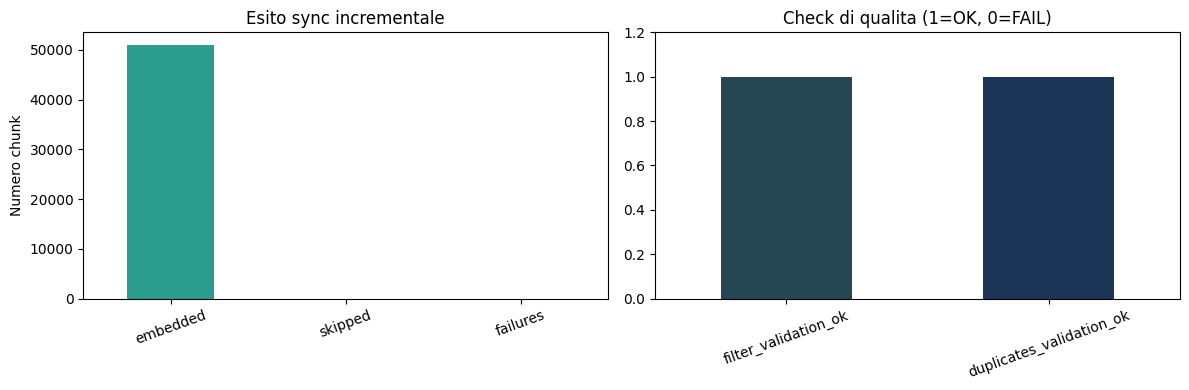

In [11]:
# Visualizzazioni pulite dello stato indexing.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sync_plot = pd.Series({
    'embedded': sync_stats.get('embedded', 0),
    'skipped': sync_stats.get('skipped', 0),
    'failures': sync_stats.get('failures', 0),
})
sync_plot.plot(kind='bar', ax=axes[0], color=['#2a9d8f', '#457b9d', '#e76f51'])
axes[0].set_title('Esito sync incrementale')
axes[0].set_ylabel('Numero chunk')
axes[0].tick_params(axis='x', rotation=20)

checks_plot = pd.Series({
    'filter_validation_ok': 1 if indexing_summary['filter_validation'].get('ok') else 0,
    'duplicates_validation_ok': 1 if indexing_summary['duplicates_validation'].get('ok') else 0,
})
checks_plot.plot(kind='bar', ax=axes[1], color=['#264653', '#1d3557'])
axes[1].set_title('Check di qualita (1=OK, 0=FAIL)')
axes[1].set_ylim(0, 1.2)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Sezione H - Reindex forzato

Per rigenerare tutti gli embeddings (anche invariati):
1. imposta `FORCE_REEMBED = True` in configurazione
2. riesegui debug embeddings + cella di indexing

Per test veloci usa `SUBSET_LIMIT`.
